# Instant Model Experiments (Small Neural Network / MLP)

We load `instant_mock.csv`, pick the sensor features, and predict `comfortValue` classes.
We split into train/val/test and run a small grid search using a Multi-Layer Perceptron (Neural Network).
Because Neural Networks are highly sensitive to unscaled data, we use a `Pipeline` to apply a `StandardScaler` before passing the data to the MLP. The network is kept shallow (1 hidden layer) to avoid overfitting on a small dataset.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

In [2]:
import os
import pandas as pd

data_path = '../../data/processed/instant_mock.csv'

target_col = 'comfortValue'
group_col = 'room' 
feature_cols = ['humidity', 'light', 'temperature', 'noise', 'co2']

df = pd.read_csv(data_path)

columns_to_keep = feature_cols + [target_col, group_col]
df = df[columns_to_keep].dropna()

if pd.api.types.is_numeric_dtype(df[target_col]):
    df[target_col] = df[target_col].round().astype(int)

print(f"Rooms found: {df[group_col].unique()}")
print(f"Rows after cleaning: {len(df):,}")
display(df.head())

Rooms found: ['Lab 4.2' 'Room 2.5' 'Room 2.12' 'Lab 2.2']
Rows after cleaning: 1,812


,humidity,light,temperature,noise,co2,comfortValue,room
0,4225.0,7.669843,25.1,7.810250,0.001916,4,Lab 4.2
1,4225.0,7.669843,25.1,7.810250,0.001916,5,Lab 4.2
2,4096.0,6.835845,25.2,7.810250,0.001976,3,Lab 4.2
3,4096.0,6.835845,25.2,7.810250,0.001976,4,Lab 4.2
4,3969.0,7.039566,25.3,7.745967,0.001938,4,Lab 4.2


In [3]:
from sklearn.model_selection import GroupShuffleSplit

X = df[feature_cols]
y = df[target_col]
groups = df[group_col]

# 1. Split into Train (2 rooms) and Temp (2 rooms)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
train_idx, temp_idx = next(gss1.split(X, y, groups=groups))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_temp, y_temp = X.iloc[temp_idx], y.iloc[temp_idx]
groups_temp = groups.iloc[temp_idx]

# 2. Split Temp into Val (1 room) and Test (1 room)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups=groups_temp))

X_val, y_val = X_temp.iloc[val_idx], y_temp.iloc[val_idx]
X_test, y_test = X_temp.iloc[test_idx], y_temp.iloc[test_idx]

print(f"Train size: {len(X_train):,} (Rooms: {groups.iloc[train_idx].unique()})")
print(f"Val size:   {len(X_val):,} (Rooms: {groups_temp.iloc[val_idx].unique()})")
print(f"Test size:  {len(X_test):,} (Rooms: {groups_temp.iloc[test_idx].unique()})")

Train size: 1,285 (Rooms: ['Room 2.12' 'Lab 2.2'])
Val size:   286 (Rooms: ['Lab 4.2'])
Test size:  241 (Rooms: ['Room 2.5'])


In [4]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(random_state=42, max_iter=1000, early_stopping=True, validation_fraction=0.15))
])

param_grid = {
    'mlp__hidden_layer_sizes': [(8,), (16,)],
    'mlp__alpha': [0.0001, 0.01], 
    'mlp__learning_rate_init': [0.001, 0.005]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV F1-Macro score: {grid.best_score_:.3f}")

best_model = grid.best_estimator_

Best params: {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (8,), 'mlp__learning_rate_init': 0.005}
Best CV F1-Macro score: 0.170


--- BEST MODEL ---
Computing CV predictions...
CV Accuracy: 0.469 | Precision: 0.367 | Recall: 0.469 | F1: 0.374
Test Accuracy: 0.461 | Precision: 0.325 | Recall: 0.461 | F1: 0.363


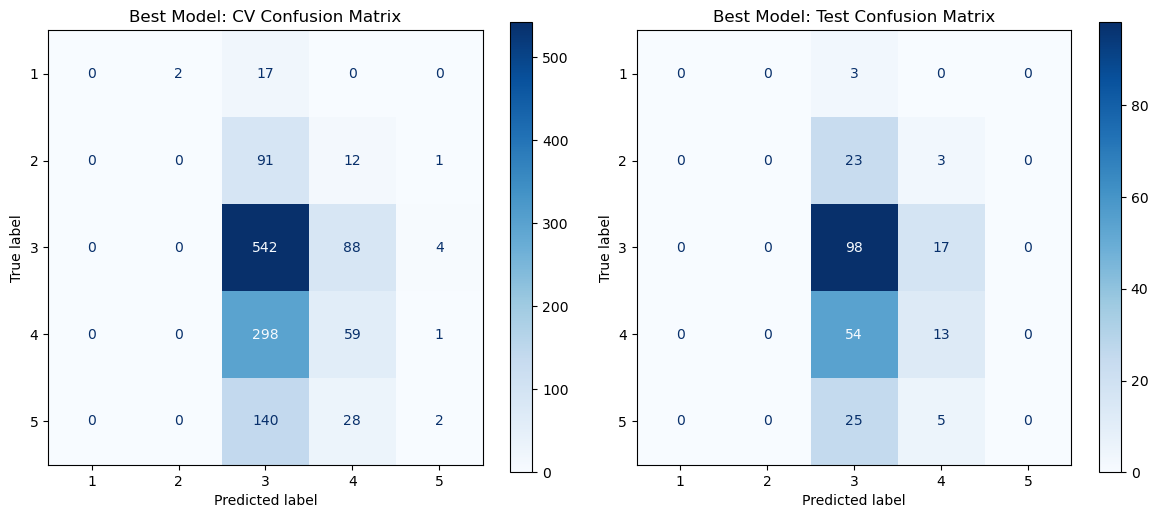

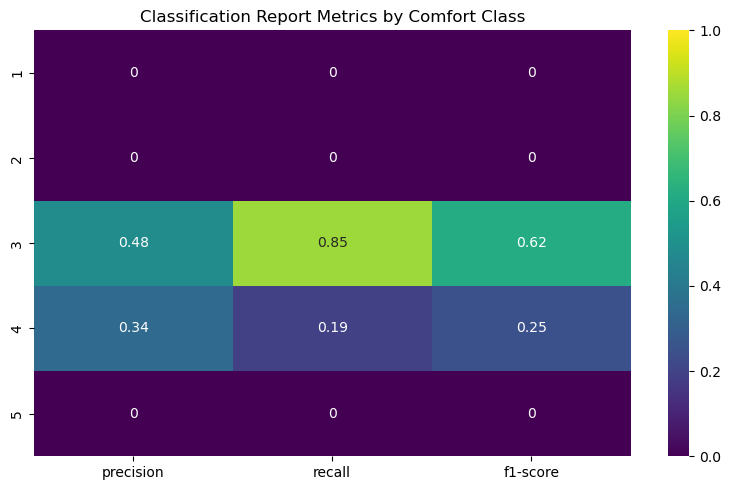

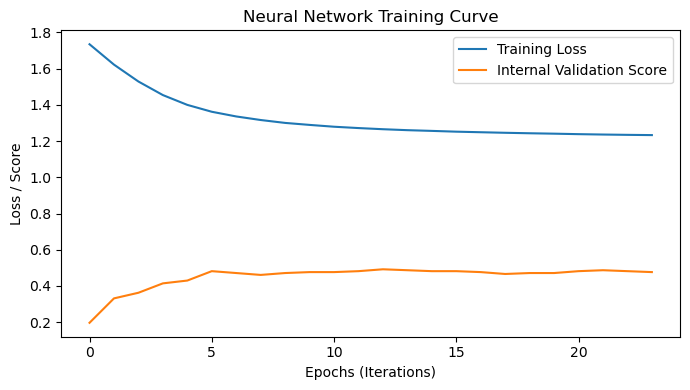

In [5]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("--- BEST MODEL ---")
print("Computing CV predictions...")
cv_preds = cross_val_predict(grid.best_estimator_, X_train, y_train, cv=5, n_jobs=-1)
cv_acc = accuracy_score(y_train, cv_preds)
cv_prec = precision_score(y_train, cv_preds, average='weighted', zero_division=0)
cv_rec = recall_score(y_train, cv_preds, average='weighted', zero_division=0)
cv_f1 = f1_score(y_train, cv_preds, average='weighted', zero_division=0)
print(f"CV Accuracy: {cv_acc:.3f} | Precision: {cv_prec:.3f} | Recall: {cv_rec:.3f} | F1: {cv_f1:.3f}")

test_preds = best_model.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)
test_prec = precision_score(y_test, test_preds, average='weighted', zero_division=0)
test_rec = recall_score(y_test, test_preds, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, test_preds, average='weighted', zero_division=0)
print(f"Test Accuracy: {test_acc:.3f} | Precision: {test_prec:.3f} | Recall: {test_rec:.3f} | F1: {test_f1:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_train, cv_preds, cmap='Blues', ax=axes[0])
axes[0].set_title('Best Model: CV Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(y_test, test_preds, cmap='Blues', ax=axes[1])
axes[1].set_title('Best Model: Test Confusion Matrix')

plt.tight_layout()
plt.show()

# Heatmap
report = classification_report(y_test, test_preds, output_dict=True, zero_division=0)
for key in ['accuracy', 'macro avg', 'weighted avg']:
    if key in report: del report[key]
report_df = pd.DataFrame(report).transpose()
plt.figure(figsize=(8, 5))
sns.heatmap(report_df[['precision', 'recall', 'f1-score']], annot=True, cmap='viridis', vmin=0, vmax=1)
plt.title('Classification Report Metrics by Comfort Class')
plt.tight_layout()
plt.show()

# Training Curve (MLP Specific)
mlp_model = best_model.named_steps['mlp']
plt.figure(figsize=(7, 4))
plt.plot(mlp_model.loss_curve_, label='Training Loss')
if hasattr(mlp_model, 'validation_scores_'):
    plt.plot(mlp_model.validation_scores_, label='Internal Validation Score')
plt.title('Neural Network Training Curve')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Loss / Score')
plt.legend()
plt.tight_layout()
plt.show()

--- OVERFITTING MODEL ---
Train Accuracy: 0.609 | Precision: 0.607 | Recall: 0.609 | F1: 0.590
Test Accuracy: 0.390 | Precision: 0.306 | Recall: 0.390 | F1: 0.343


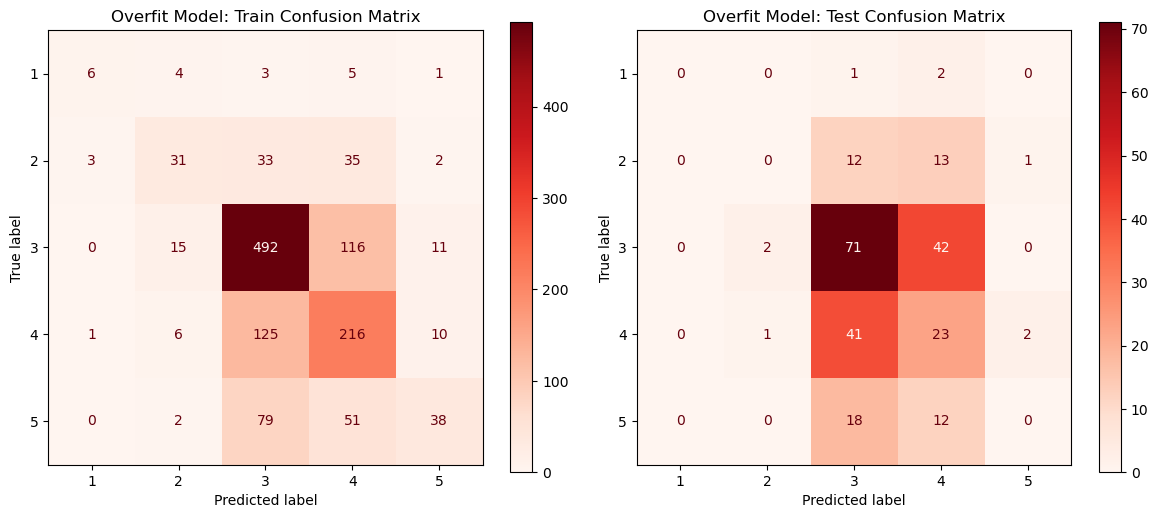

In [6]:
print("--- OVERFITTING MODEL ---")
# Using massive hidden layers, zero regularization (alpha=0), and turning off early stopping to memorize data
overfit_model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(500, 500), 
        alpha=0.0, 
        max_iter=2000, 
        early_stopping=False,
        random_state=42
    ))
])
overfit_model.fit(X_train, y_train)

train_preds_overfit = overfit_model.predict(X_train)
train_acc_overfit = accuracy_score(y_train, train_preds_overfit)
train_prec = precision_score(y_train, train_preds_overfit, average='weighted', zero_division=0)
train_rec = recall_score(y_train, train_preds_overfit, average='weighted', zero_division=0)
train_f1 = f1_score(y_train, train_preds_overfit, average='weighted', zero_division=0)
print(f"Train Accuracy: {train_acc_overfit:.3f} | Precision: {train_prec:.3f} | Recall: {train_rec:.3f} | F1: {train_f1:.3f}")

test_preds_overfit = overfit_model.predict(X_test)
test_acc_overfit = accuracy_score(y_test, test_preds_overfit)
test_prec_overfit = precision_score(y_test, test_preds_overfit, average='weighted', zero_division=0)
test_rec_overfit = recall_score(y_test, test_preds_overfit, average='weighted', zero_division=0)
test_f1_overfit = f1_score(y_test, test_preds_overfit, average='weighted', zero_division=0)
print(f"Test Accuracy: {test_acc_overfit:.3f} | Precision: {test_prec_overfit:.3f} | Recall: {test_rec_overfit:.3f} | F1: {test_f1_overfit:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train Confusion Matrix (Perfect diagonal!)
ConfusionMatrixDisplay.from_predictions(y_train, train_preds_overfit, cmap='Reds', ax=axes[0])
axes[0].set_title('Overfit Model: Train Confusion Matrix')

# Test Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, test_preds_overfit, cmap='Reds', ax=axes[1])
axes[1].set_title('Overfit Model: Test Confusion Matrix')

plt.tight_layout()
plt.show()